# Level 2 - Task 1: Restaurant Ratings Analysis

## Objective

The objective of this task is to analyze restaurant ratings and customer voting patterns.

### This task includes:

- Analyzing the distribution of aggregate ratings.
- Identifying the most common rating range.
- Calculating the average number of votes received by restaurants.
- Visualizing rating distributions.

### Libraries Used

- Pandas
- Matplotlib
- Seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("../Dataset.csv")

## Step 1: Explore Aggregate Ratings

The aggregate rating column is analyzed to understand the distribution of restaurant ratings.

In [5]:
df["Aggregate rating"].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

## Step 2: Create Rating Distribution Histogram

A histogram is used to visualize how restaurant ratings are distributed.


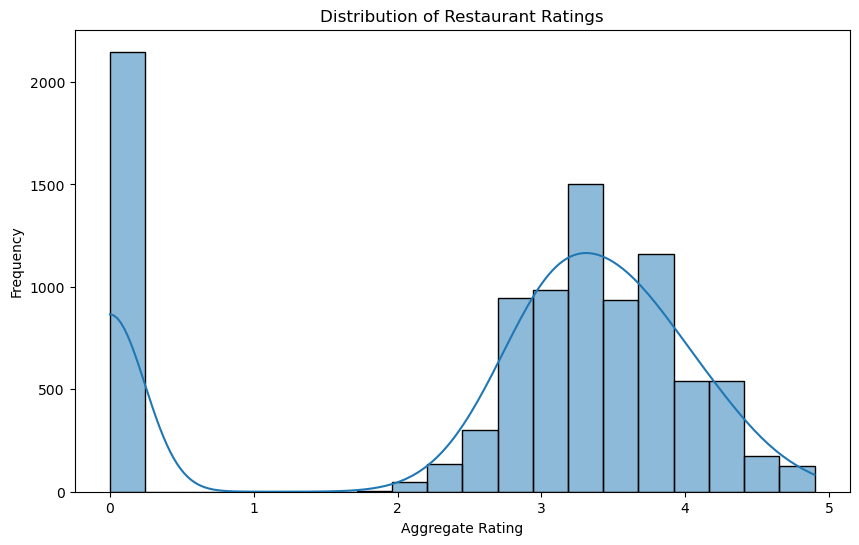

In [8]:
os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(10,6))

sns.histplot(
    df["Aggregate rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Frequency")

plt.savefig(
    "../images/rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 3: Create Rating Categories

Ratings are grouped into ranges to identify the most common rating interval.

In [11]:
rating_bins = [0, 1, 2, 3, 4, 5]

rating_labels = [
    "0-1",
    "1-2",
    "2-3",
    "3-4",
    "4-5"
]

df["Rating Range"] = pd.cut(
    df["Aggregate rating"],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True
)

rating_range_counts = df["Rating Range"].value_counts().sort_index()

rating_range_counts

Rating Range
0-1    2148
1-2      10
2-3    1891
3-4    4388
4-5    1114
Name: count, dtype: int64

## Step 4: Identify the Most Common Rating Range

The rating range with the highest number of restaurants is determined.

In [14]:
most_common_range = rating_range_counts.idxmax()

print("Most Common Rating Range:", most_common_range)

Most Common Rating Range: 3-4


## Step 5: Visualize Rating Ranges

The following chart shows the number of restaurants in each rating category.

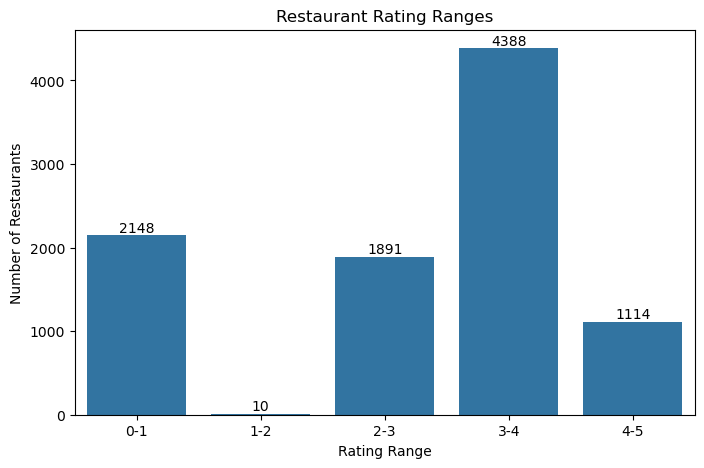

In [17]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=rating_range_counts.index,
    y=rating_range_counts.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Restaurant Rating Ranges")
plt.xlabel("Rating Range")
plt.ylabel("Number of Restaurants")

plt.savefig(
    "../images/rating_ranges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 6: Calculate Average Votes

The average number of customer votes received by restaurants is calculated.

In [20]:
average_votes = df["Votes"].mean()

print("Average Votes Received:", round(average_votes, 2))

Average Votes Received: 156.91


# Business Insight

- Restaurants with higher ratings generally attract more customer attention.
- Understanding rating distributions helps businesses identify market standards.
- Customer votes indicate popularity and engagement levels.


# Conclusion

## Key Findings

- The distribution of restaurant ratings was analyzed.
- The most common rating range was identified.
- Average customer votes were calculated.
- Visualizations provide a clear understanding of restaurant performance.

This analysis helps businesses evaluate customer satisfaction and popularity.